### important table For transformation 

| `df.skew()` value | Distribution Type           | What it Means             | Suggested Transformation     |
| ----------------- | --------------------------- | ------------------------- | ---------------------------- |
| **-0.5 to 0.5**   | Approximately **Normal**    | Data is fairly symmetric  | **No transformation needed** |
| **0.5 to 1**      | **Moderately Right Skewed** | Tail extends to the right | **Square Root (`sqrt`)**     |
| **> 1**           | **Highly Right Skewed**     | Very long right tail      | **Log (`log` or `log1p`)**   |
| **-1 to -0.5**    | **Moderately Left Skewed**  | Tail extends to the left  | **Square (`x²`)**            |
| **< -1**          | **Highly Left Skewed**      | Strong left tail          | **Power transform / square** |


In [1]:
import pandas as pd 
import numpy as np


In [2]:
df = pd.read_csv('concrete_data.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

In [5]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [8]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Strength',axis =1), df['Strength'], test_size= 0.2, random_state=42)


In [9]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)

0.6275531792314848

In [13]:
# now to confirm

cross_val_score(lr,x_train,y_train, cv =10 , scoring ='r2').mean()

np.float64(0.5894185601991604)

In [ ]:
# this code for just me to try decision tree regressor and see if it performs better than linear regression

from sklearn.tree import DecisionTreeRegressor

dr = DecisionTreeRegressor()

dr.fit(x_train,y_train)
y_pred = dr.predict(x_test)
r2_score(y_test,y_pred)

0.8288612614102766

In [17]:
cross_val_score(dr, x_train,y_train,cv = 10, scoring="r2").mean()

np.float64(0.8310794687632572)

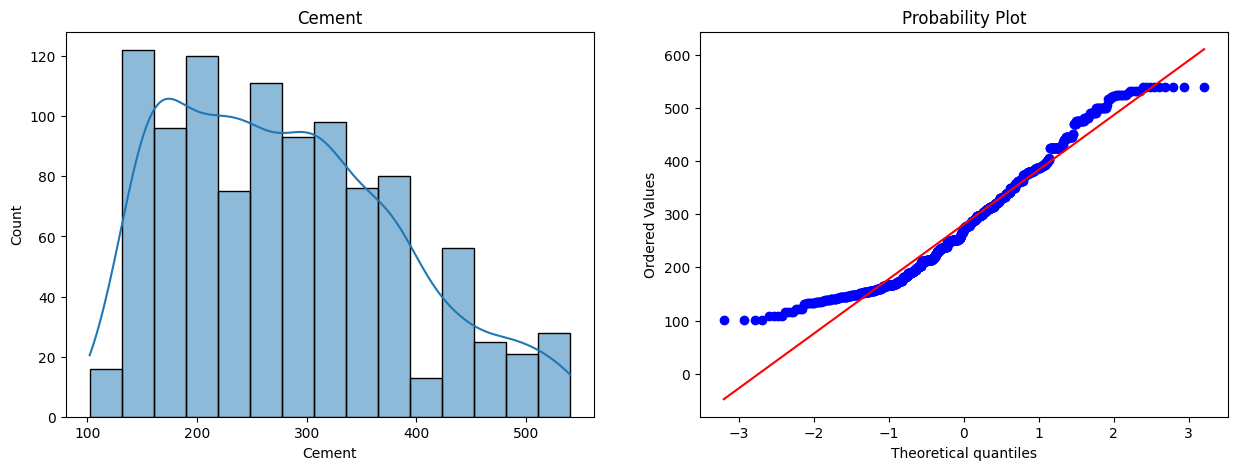

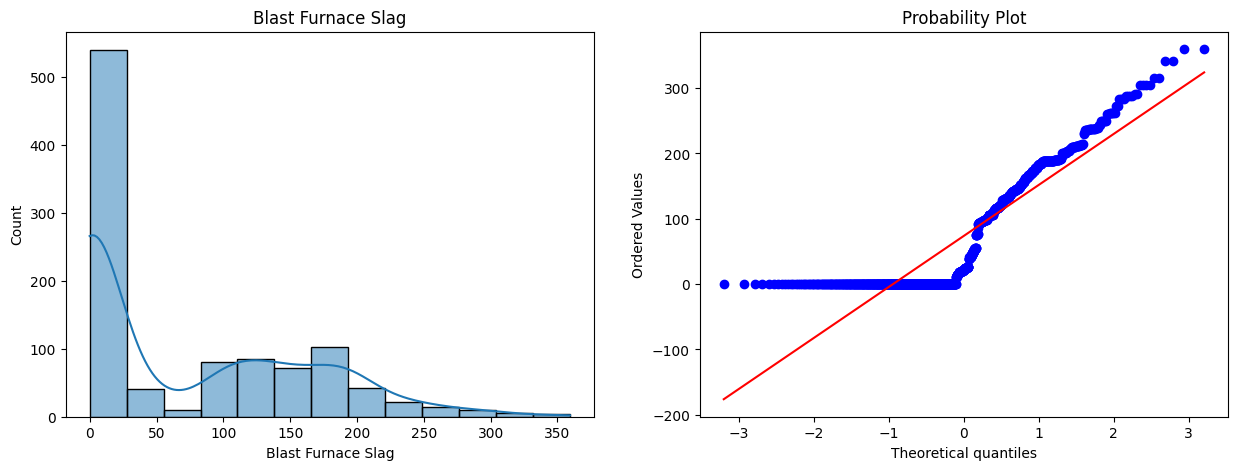

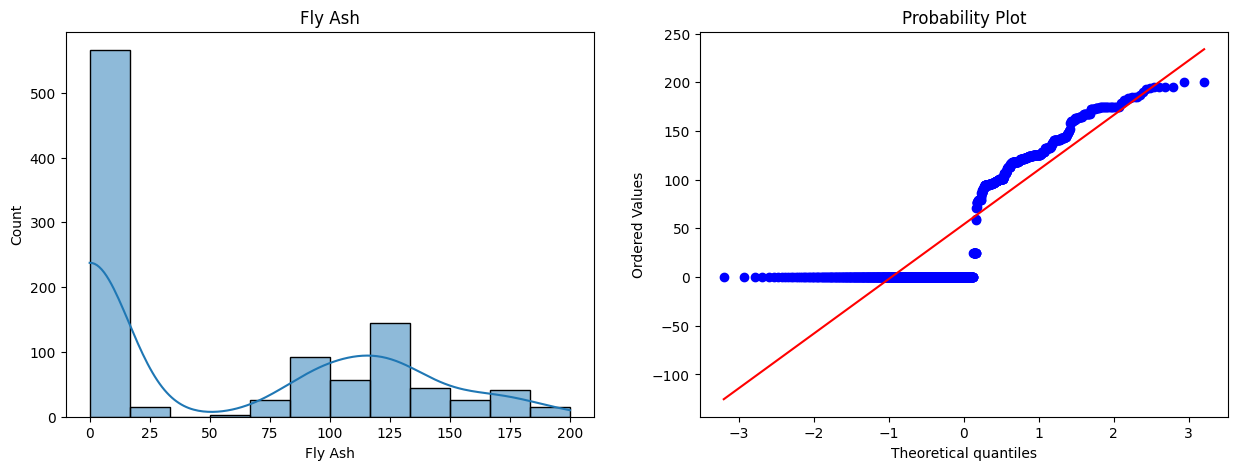

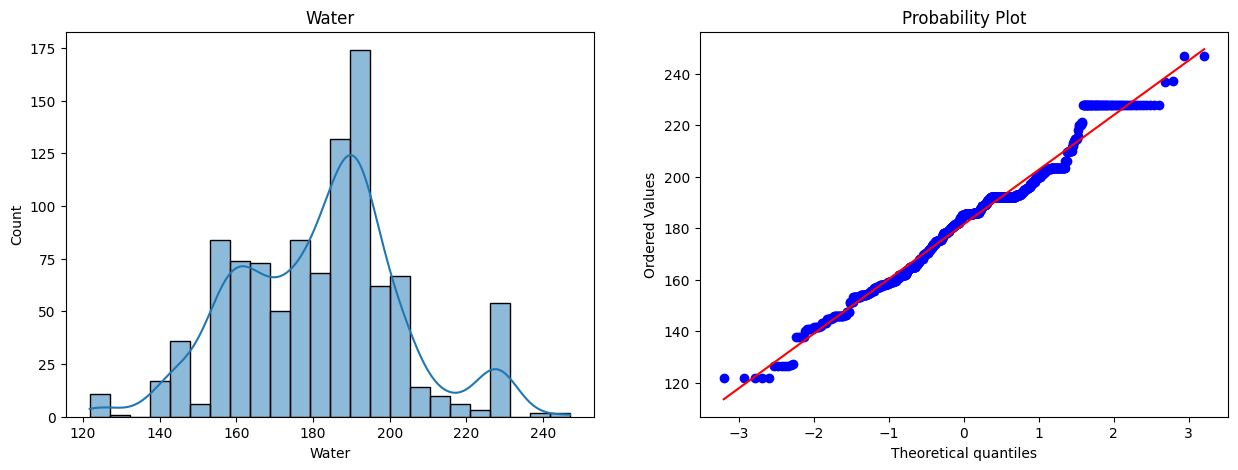

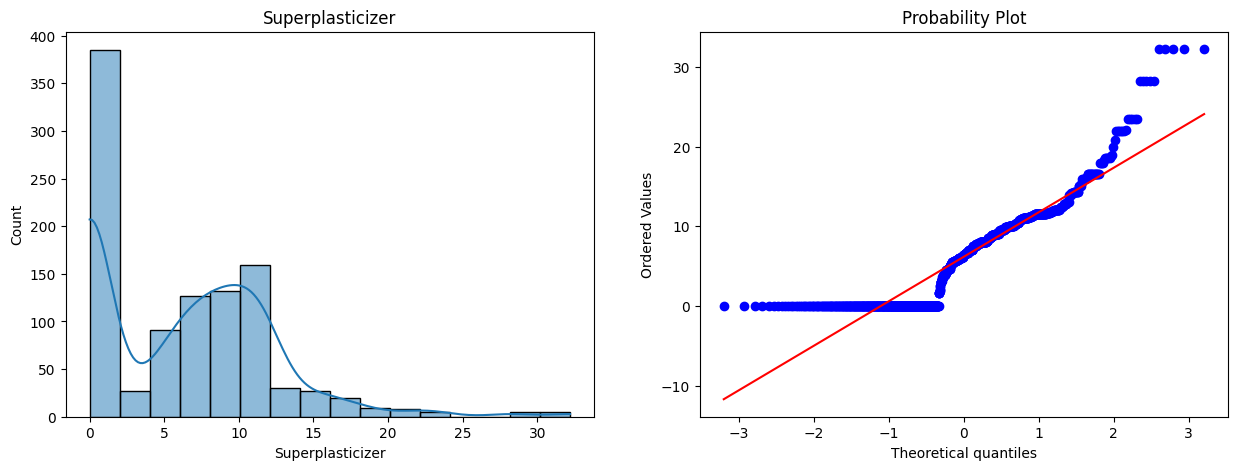

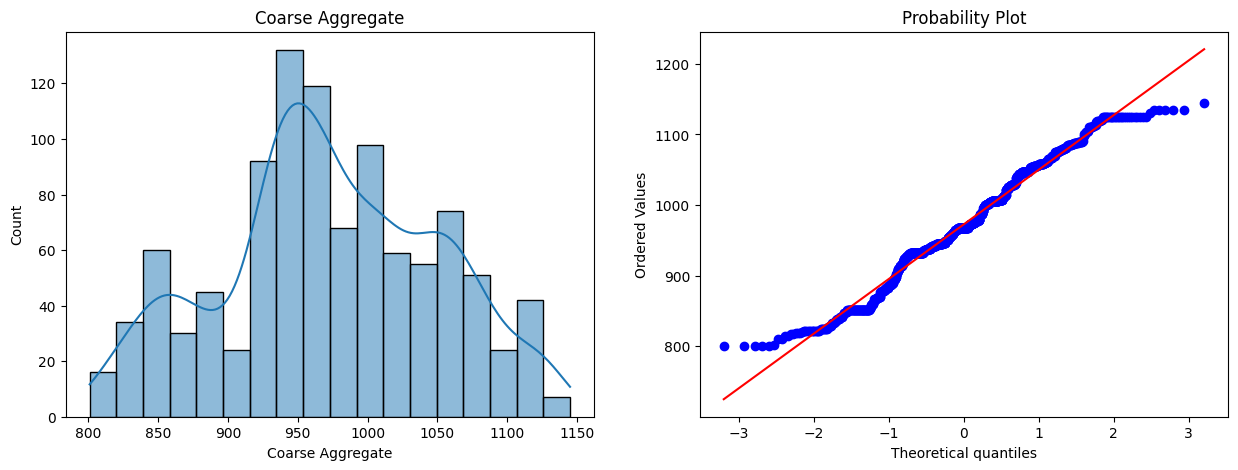

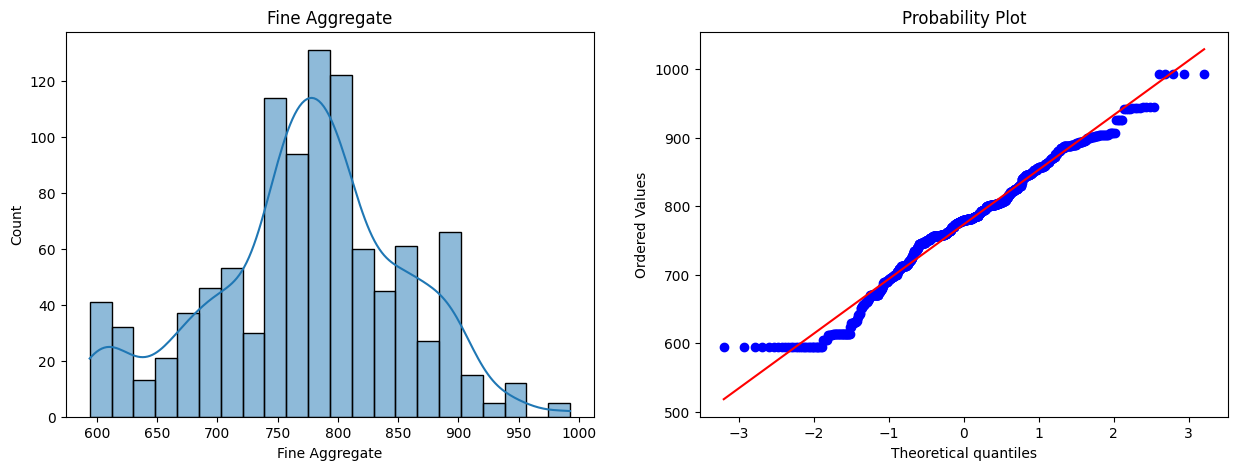

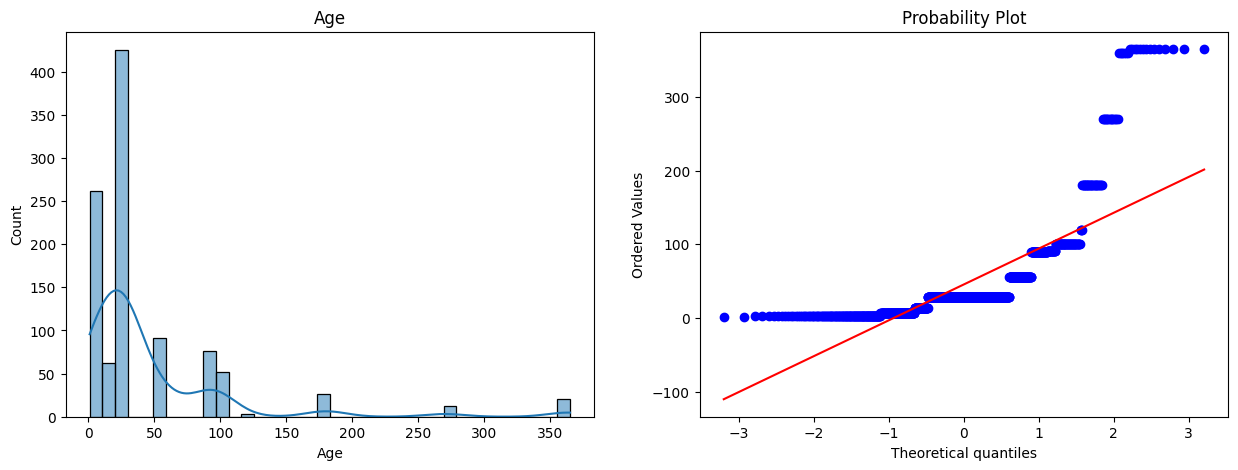

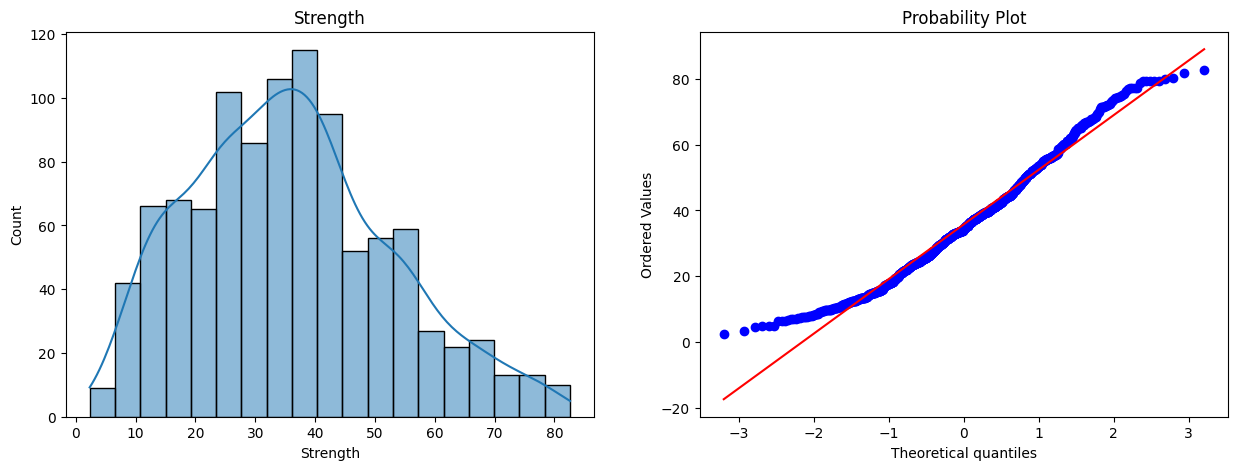

In [29]:
# now let us focus back on linear regression and try to improve it by transforming the data 

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

for columns in df.columns:
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    sns.histplot(df[columns], kde = True)
    plt.title(columns)
    
    plt.subplot(122)
    stats.probplot(df[columns], dist = "norm", plot = plt)
    plt.show()

In [31]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [33]:
print(df.Age.skew())
print(df['Blast Furnace Slag'].skew())
print(df['Fly Ash'].skew())
print(df.Superplasticizer.skew())
print(df.Cement.skew())

3.26917740063459
0.8007168956061772
0.5373539058066844
0.9072025748672465
0.509481178871773


### important table 

| `df.skew()` value | Distribution Type           | What it Means             | Suggested Transformation     |
| ----------------- | --------------------------- | ------------------------- | ---------------------------- |
| **-0.5 to 0.5**   | Approximately **Normal**    | Data is fairly symmetric  | **No transformation needed** |
| **0.5 to 1**      | **Moderately Right Skewed** | Tail extends to the right | **Square Root (`sqrt`)**     |
| **> 1**           | **Highly Right Skewed**     | Very long right tail      | **Log (`log` or `log1p`)**   |
| **-1 to -0.5**    | **Moderately Left Skewed**  | Tail extends to the left  | **Square (`x²`)**            |
| **< -1**          | **Highly Left Skewed**      | Strong left tail          | **Power transform / square** |


In [36]:
# First we will be using the box-cox to solve the skewnwss 
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method ='box-cox')

x_train_transformed_box_cox = pt.fit_transform(x_train+0.00000001)
x_test_transformed_box_cox  = pt.transform(x_test+ 0.00000001)

lr.fit(x_train_transformed_box_cox,y_train)

y_pred_transformed_boxcox = lr.predict(x_test_transformed_box_cox)

print(r2_score(y_test,y_pred_transformed_boxcox))

print(cross_val_score(lr,x_train_transformed_box_cox,y_train, cv = 10 , scoring= 'r2').mean())


0.8038298017767421
0.7911938997837348


In [ ]:
x_train_transformed_box_cox = pd.DataFrame(x_train_transformed_box_cox, columns = x_train.columns) ## Coverting the array to dataframe to be able to plot the histogram 

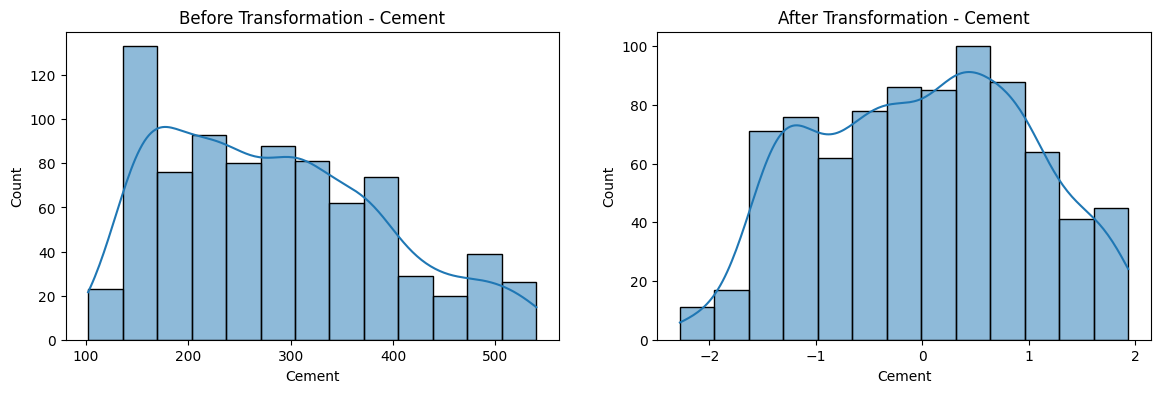

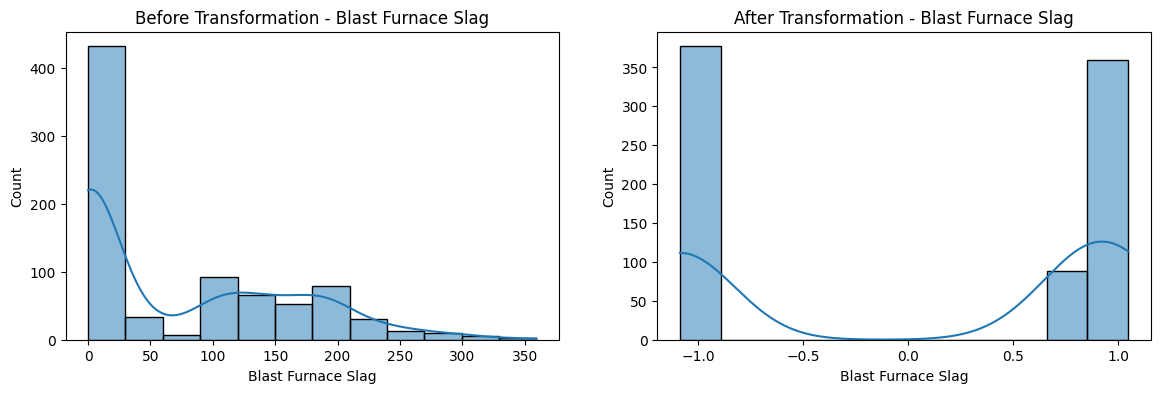

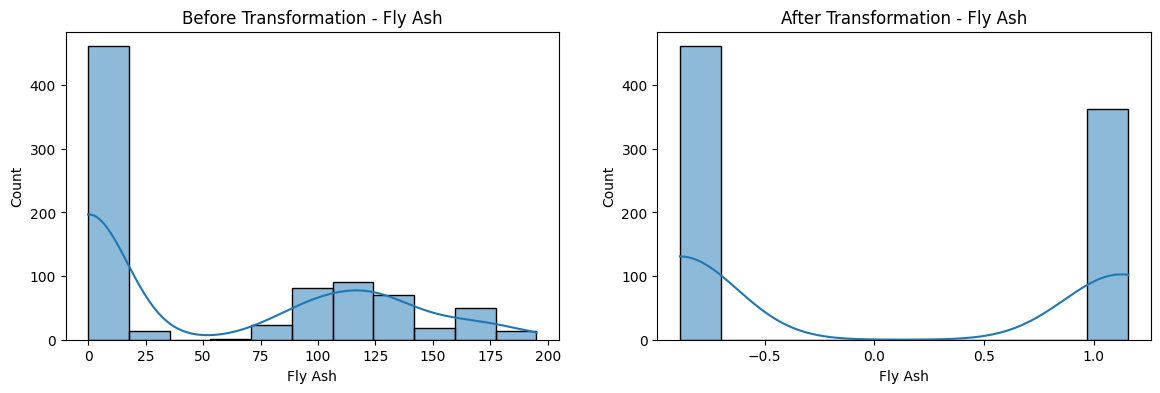

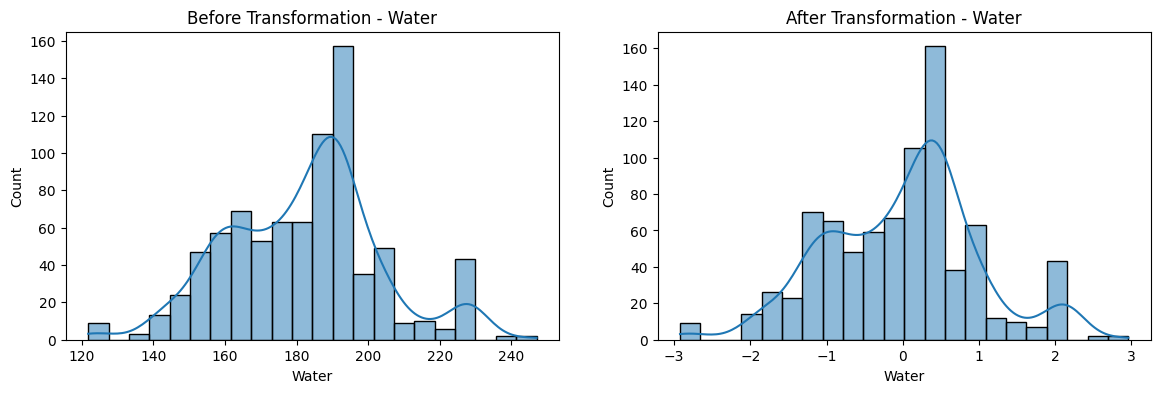

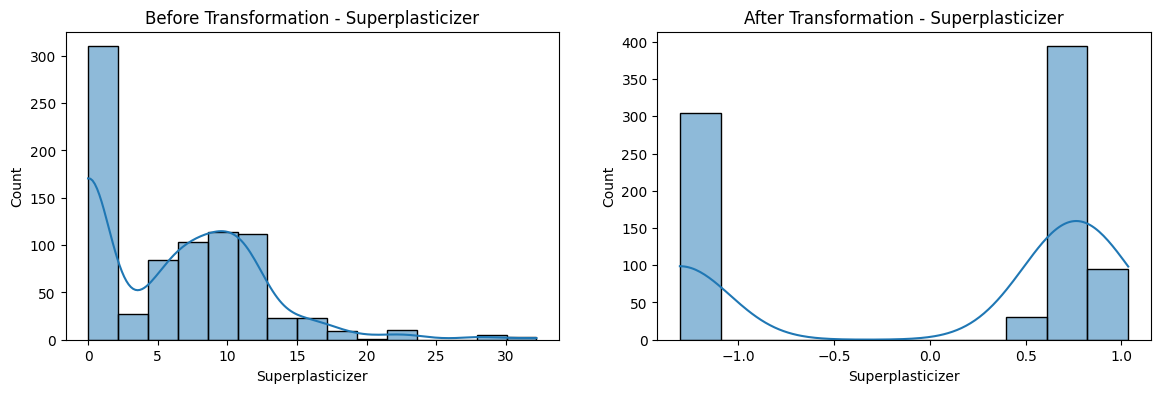

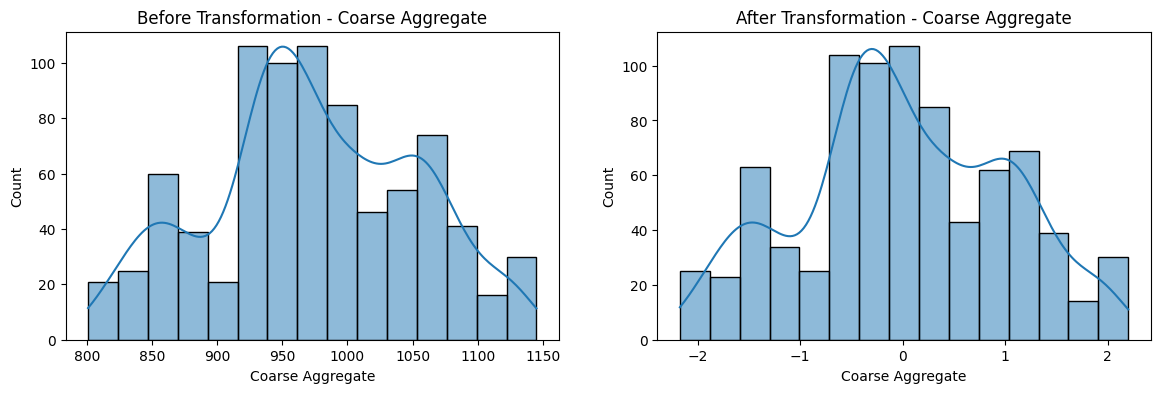

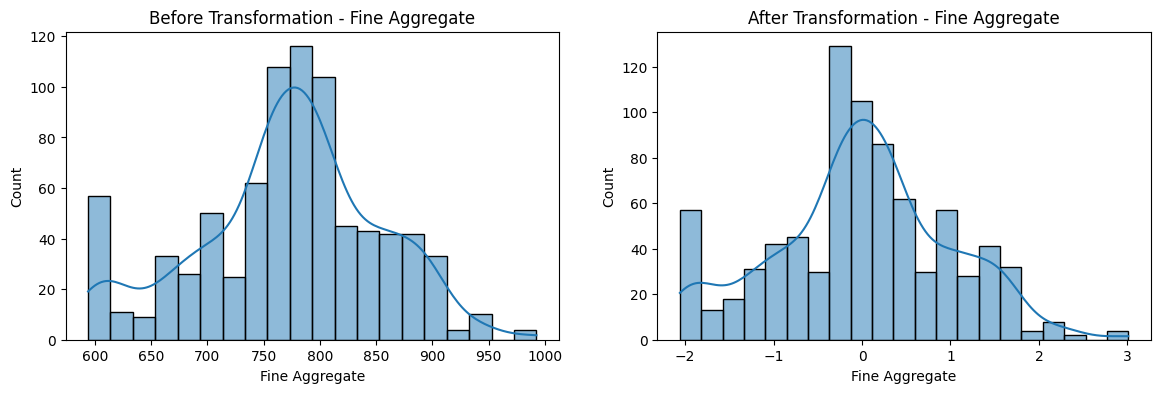

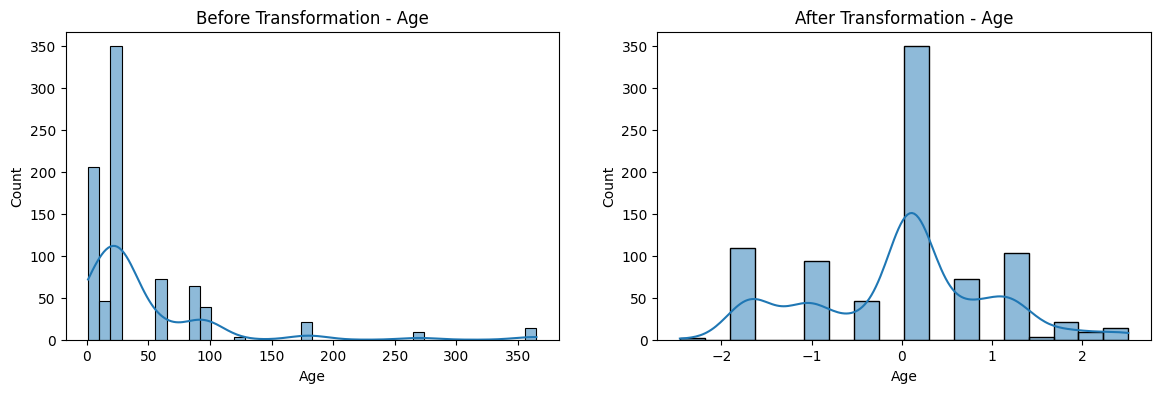

In [40]:
# representation of the grpahs before and after transformation based on thte box-cox transformation 

for col in x_train.columns:
    
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde = True)
    plt.title(f'Before Transformation - {col}')
    
    plt.subplot(122)
    sns.histplot(x_train_transformed_box_cox[col], kde = True)
    plt.title(f'After Transformation - {col}')
    
    plt.show()
    

## Major change was seen in the Age column 

In [42]:
## Now we will be using the Yeo Johnson tranformation to solve the skewness 

pt2  =PowerTransformer()

x_train_tranformed_yeo= pt2.fit_transform(x_train)
x_test_transformed_yeo = pt2.transform(x_test)

lr.fit(x_train_tranformed_yeo,y_train)
y_pred_tranformed_yeo = lr.predict(x_test_transformed_yeo)

print(r2_score(y_test,y_pred_tranformed_yeo))
print(cross_val_score(lr,x_train_tranformed_yeo,y_train,cv = 10, scoring = 'r2').mean())


0.8161906511066099
0.7936885680839875


In [43]:
x_train_tranformed_yeo = pd.DataFrame(x_train_tranformed_yeo, columns = x_train.columns)

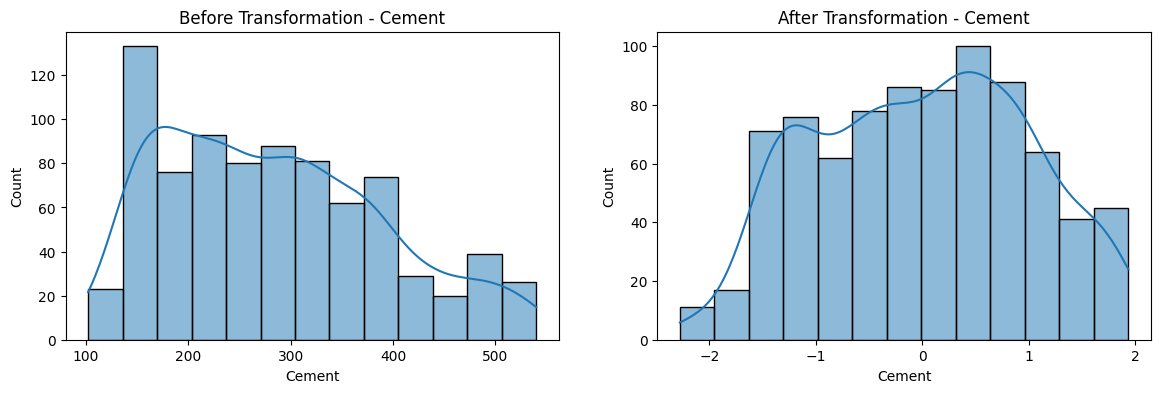

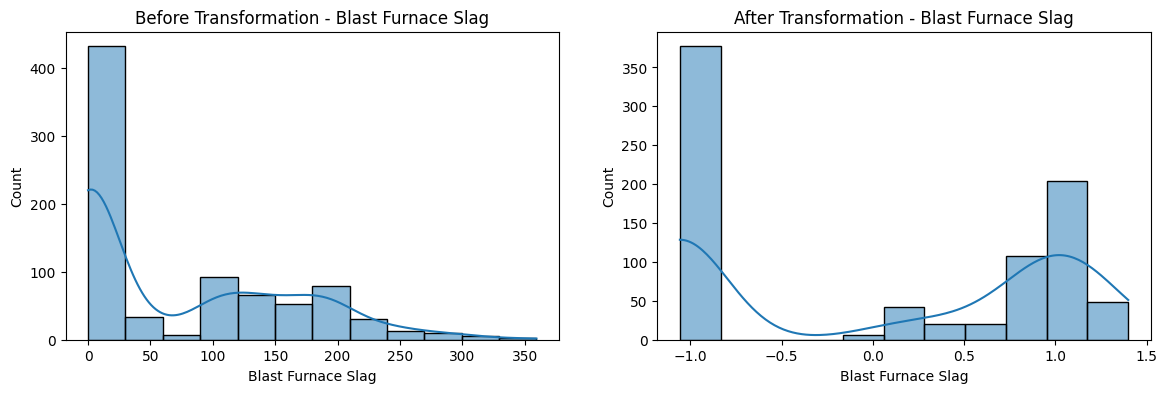

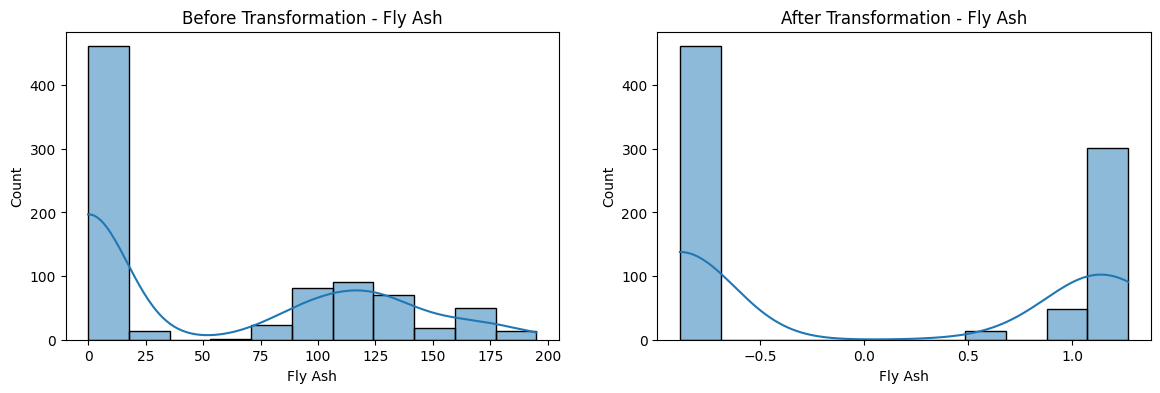

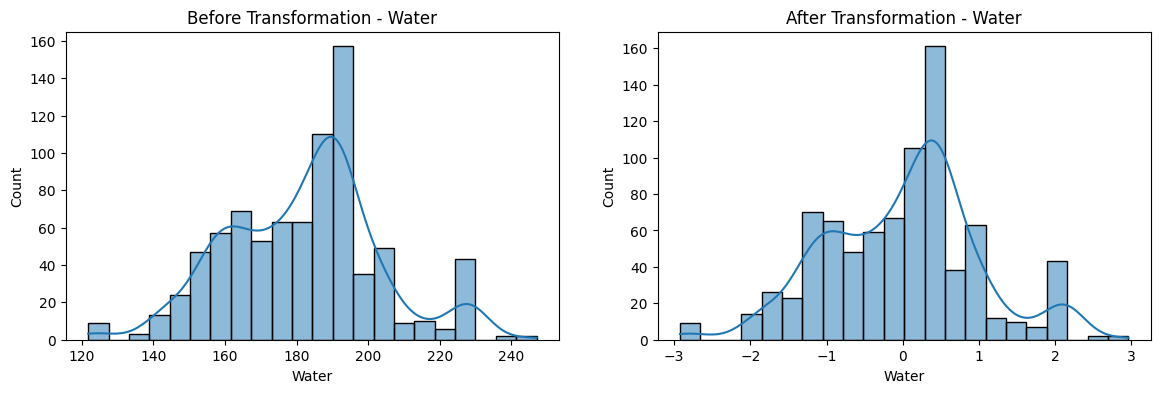

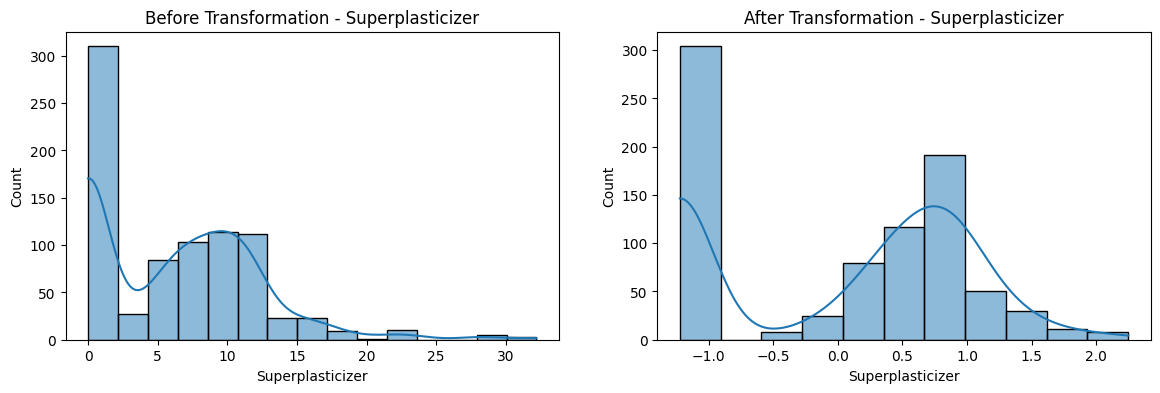

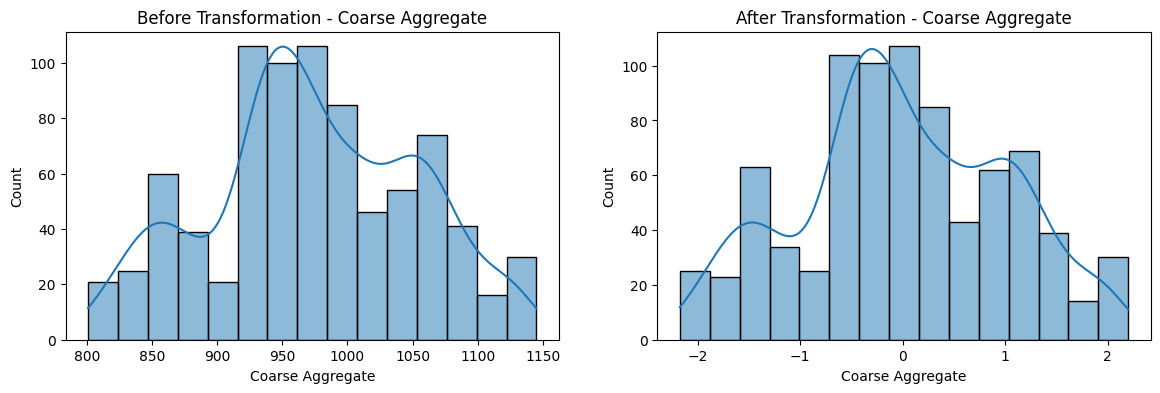

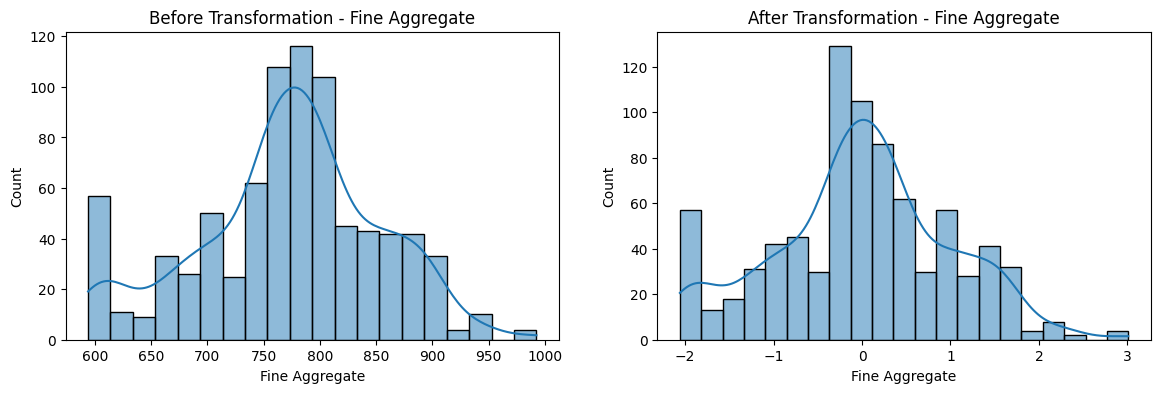

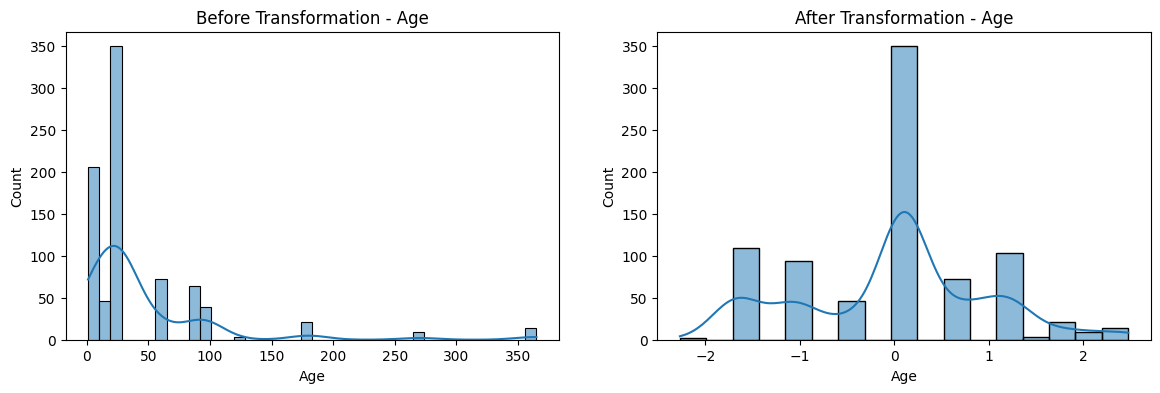

In [44]:
for col in x_train.columns:
    
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde = True)
    plt.title(f'Before Transformation - {col}')
    
    plt.subplot(122)
    sns.histplot(x_train_tranformed_yeo[col], kde = True)
    plt.title(f'After Transformation - {col}')
    
    plt.show()